# Imports

In [ ]:
#test
#test on VScodes

In [ ]:
import torch
print(torch.__version__)

2.11.0+cu128


In [ ]:
import numpy

In [28]:
#Installs on colab
def running_on_colab():
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False

if running_on_colab():
    print("Running on Colab. Installing dependencies...")
    !pip install -q atomai neuraloperator ipympl ipywidgets hoffmanstmpy

    from google.colab import output
    output.enable_custom_widget_manager()

    !git clone -b ayush_dev --single-branch https://github.com/gnganesh99/NN_Error.git
    %cd NN_Error

    print("Colab setup complete.")

Running on Colab. Installing dependencies...
Cloning into 'NN_Error'...
remote: Enumerating objects: 483, done.
remote: Counting objects: 100% (192/192), done.
remote: Compressing objects: 100% (164/164), done.
remote: Total 483 (delta 110), reused 62 (delta 28), pack-reused 291 (from 1)
Receiving objects: 100% (483/483), 139.58 MiB | 15.32 MiB/s, done.
Resolving deltas: 100% (270/270), done.
/content/NN_Error/NN_Error
Colab setup complete.


In [29]:
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
import os
from scipy.ndimage import zoom


try:
    get_ipython().run_line_magic("matplotlib", "widget")
except (ValueError, RuntimeError):
    get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt


# Make package and notebook-local helper modules importable whether this starts in repo root or notebooks/
repo_root = Path.cwd() if (Path.cwd() / "src" / "nnerror").exists() else Path.cwd().parent.parent
src_root = str((repo_root / "src").resolve())
nb_root = str((repo_root / "notebooks"/"STM").resolve())
for import_root in (src_root, nb_root):
    if import_root not in sys.path:
        sys.path.insert(0, import_root)




from nnerror.networks import FNO_im2spec, CustomDecoder, im2spec
from nnerror.training_functions import err_estimation, train_model, predict_spectra, norm_0to1, predict_posterior, append_training_set
from nnerror.plot_functions import plot_only_training_loss, plot_training_loss, \
    plot_error_prediction, plot_spectra, plot_error_prediction_3d, plot_scale_slider, plot_latent_space, cluster_latent_space, plot_latent_distribution, plot_scale_specific_error_and_acquisition_maps
from nnerror.utils import append_multiscale_data, edges_zeroed_image, interpolated_center_crop, paired_images_spectra_1
from mpl_toolkits.axes_grid1 import make_axes_locatable

ImportError: cannot import name 'plot_scale_specific_error_and_acquisition_maps' from 'nnerror.plot_functions' (/content/NN_Error/src/nnerror/plot_functions.py)

In [3]:
from stm_utils import Sxm_Image
from CITS_Class import CITS_Analysis


# Get data

In [4]:
data_folder = r"data/large_area" if not running_on_colab() else r"notebooks/STM/data/large_area"

img_sxm = os.path.join(data_folder, "EnZn2As2017.sxm")
spectra_sxm = os.path.join(data_folder, "EuZn2As2003.3ds")
#Get the morphology image
full_image = Sxm_Image(img_sxm).image()
full_image = norm_0to1(full_image)

#Get the current spectra
cits_obj = CITS_Analysis(spectra_sxm)
hyperspectra = cits_obj.current

full_image.shape, hyperspectra.shape

File import successful.


((512, 512), (80, 250, 121))

In [5]:
WS = 32
WS_init = 4
d_WS = 4
n_epochs_im2spec = 100
n_epochs_error = 100
error_type = "L1" # "L1", "L2", or "cos"
append_image_type = 'pad' #pad, interpolate
model_type = 'im2spec'

(1024, 32, 32) (1024, 121) (1024, 2)
[30. 30.]


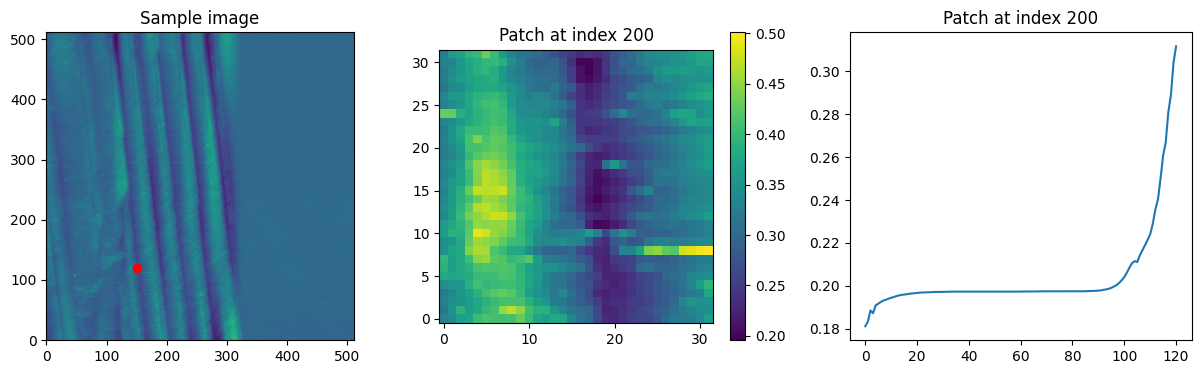

In [6]:


images, spectra, coordinates = paired_images_spectra_1(full_image, cits_obj, hyperspectra, window_size = WS,
                                                       coordinate_step = 15, image_norm=False, spectra_norm = False)

print(images.shape, spectra.shape, coordinates.shape)

print(coordinates[0])
fig, ax = plt.subplots(1, 3, figsize = (15, 4))


idx = 200

ax[0].imshow(full_image, origin = 'lower')
ax[0].scatter(coordinates[idx, 1], coordinates[idx, 0], c ="r")
ax[0].set_title("Sample image")


im = ax[1].imshow(images[idx], origin = 'lower')
fig.colorbar(im, ax=ax[1])
ax[1].set_title(f"Patch at index {idx}")
ax[2].plot(spectra[idx])
ax[2].set_title(f"Patch at index {idx}")

plt.show()

In [7]:
# coordinates are reversed.
swap_coordinates = coordinates.copy()
swap_coordinates = swap_coordinates[:, [1, 0]]
swap_coordinates.shape

(1024, 2)

## Train/test split

In [8]:
images_all = images.copy()
spectra_all = spectra.copy()
swap_coordinates_all = swap_coordinates.copy()

In [9]:
from sklearn.model_selection import train_test_split

images_train, images_test, spectra_train, spectra_test, s_coords_train, s_coords_test = train_test_split(
images_all, spectra_all, swap_coordinates_all, test_size = 0.2, random_state=42
)

initial_trainsize = images_train.shape[0]
print("images_train shape:", images_train.shape)
print("images_test shape:", images_test.shape)
print("spectra_train shape:", spectra_train.shape)
print("spectra_test shape:", spectra_test.shape)

images_train shape: (819, 32, 32)
images_test shape: (205, 32, 32)
spectra_train shape: (819, 121)
spectra_test shape: (205, 121)


## Augment across scales

In [10]:
images, spectra, scale_coordinates = append_multiscale_data(images_all, spectra_all, scales=np.arange(WS_init, WS, d_WS),
                                                            coordinates=swap_coordinates_all,
                                                            append_image_type=append_image_type)

Augmented images shape: (8192, 32, 32), Augmented spectra shape: (8192, 121), Augmented coordinates shape: (8192, 3)


In [11]:
images_tr_aug, spectra_tr_aug, _ = append_multiscale_data(images_train, spectra_train, scales=np.arange(WS_init, WS, d_WS),
                                                            coordinates=s_coords_train,
                                                            append_image_type=append_image_type)



images_test_aug, spectra_test_aug, _ = append_multiscale_data(images_test, spectra_test, scales=np.arange(WS_init, WS, d_WS),
                                                            coordinates=s_coords_test,
                                                            append_image_type=append_image_type)

print("images_train shape:", images_tr_aug.shape)
print("images_test shape:", images_test_aug.shape)

Augmented images shape: (6552, 32, 32), Augmented spectra shape: (6552, 121), Augmented coordinates shape: (6552, 3)
Augmented images shape: (1640, 32, 32), Augmented spectra shape: (1640, 121), Augmented coordinates shape: (1640, 3)
images_train shape: (6552, 32, 32)
images_test shape: (1640, 32, 32)


## Model dimensions

In [12]:

print("images shape:", images.shape)
print("spectra shape:", spectra.shape)
in_dim = images[0].shape  # Input dimensions (image height and width)
out_dim = len(spectra[0])  # Output dimensions (spectra length)

images shape: (8192, 32, 32)
spectra shape: (8192, 121)


# Train im2spec

## IM2SPEC model

In [13]:
# ----------------------------
# 2) Fit FNO_im2spec model
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if model_type == 'FNO':

  # FNO_im2spec mode. Trains better with interpolation based augmentation.
  imspec_model = FNO_im2spec(
      target_size=out_dim,
      latent_dim=3,
      hidden_channels=32,
      n_modes=(16, 16),
      n_layers=4,
  ).to(device)

elif model_type == 'im2spec':

  # Use this normal im2spec. Augmentation by padding works better here.
  imspec_model = im2spec(feature_size=in_dim, target_size=out_dim, latent_dim=3).to(device)

else:
  raise ValueError(f"Unknown model type: {model_type}")


 91%|█████████ | 91/100 [00:39<00:04,  2.08it/s, train_loss=0.0011, val_loss=0.0017]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:43<00:00,  2.30it/s, train_loss=0.0010, val_loss=0.0017]
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.

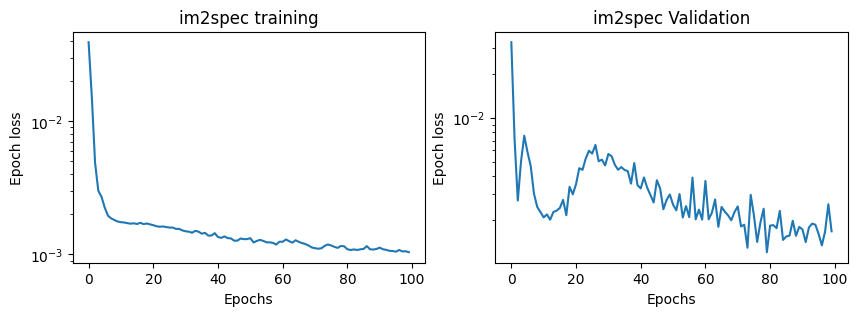

im2spec final train loss: 0.0010390596774717171
im2spec final internal val loss: 0.0016745520489556448
im2spec held-out test loss: 0.0019989979919046164


In [14]:


im2spec_training_dataset = TensorDataset(
    torch.tensor(images_tr_aug, dtype=torch.float32),
    torch.tensor(spectra_tr_aug, dtype=torch.float32),
)

im2spec_val_dataset = TensorDataset(
    torch.tensor(images_test_aug, dtype=torch.float32),
    torch.tensor(spectra_test_aug, dtype=torch.float32),
)

# train_model creates its own validation split from the dataset above.
# Keep images_test/spectra_test as an external held-out test set.

plot_im2spec_training = True

imspec_model, im2spec_train_loss, im2spec_val_loss = train_model(
    imspec_model,
    im2spec_training_dataset,
    n_batches=6,
    lr=1e-3,
    patience=10,
    n_epochs=n_epochs_im2spec,
    partial_train=False,
    val_dataset=im2spec_val_dataset,  # if not provided, train_model will split off its own validation set from the training dataset
    use_swa = True,
)

if plot_im2spec_training:
    plot_only_training_loss([im2spec_train_loss], [im2spec_val_loss])

imspec_model.eval()
with torch.no_grad():
    x_test = torch.tensor(images_test, dtype=torch.float32, device=device)
    y_test = torch.tensor(spectra_test, dtype=torch.float32, device=device)
    test_pred = imspec_model.predict(x_test)
    im2spec_test_loss = torch.nn.functional.mse_loss(test_pred, y_test).item()

print("im2spec final train loss:", im2spec_train_loss[-1])
print("im2spec final internal val loss:", im2spec_val_loss[-1])
print("im2spec held-out test loss:", im2spec_test_loss)


# Estimate error

In [15]:
# ----------------------------
# 3) Build error targets using err_estimation
# ----------------------------
error_mean, error_std, error_vector = err_estimation(imspec_model, images_tr_aug, spectra_tr_aug, error_type=error_type)
error_targets = error_mean.astype(np.float32).reshape(-1, 1)


print("error_mean shape:", error_mean.shape)
print("error_vector shape:", error_vector.shape)
print("error_targets shape:", error_targets.shape)


# ----------------------------
# 4) Fuse im2spec encoder with CustomDecoder
# ----------------------------
with torch.no_grad():
    latent_dim = imspec_model.encoder(torch.tensor(images[:1], dtype=torch.float32, device=device).unsqueeze(1)).shape[1]

error_model = CustomDecoder(encoder=imspec_model.encoder, embed_dim=latent_dim, target_size=1).to(device)

error_mean shape: (6552,)
error_vector shape: (6552, 121)
error_targets shape: (6552, 1)


## Train error model

100%|██████████| 100/100 [00:30<00:00,  3.24it/s, train_loss=0.0003, val_loss=0.0004]


error model final train loss: 0.0002652827575470188
error model final val loss: 0.00040792034373485616


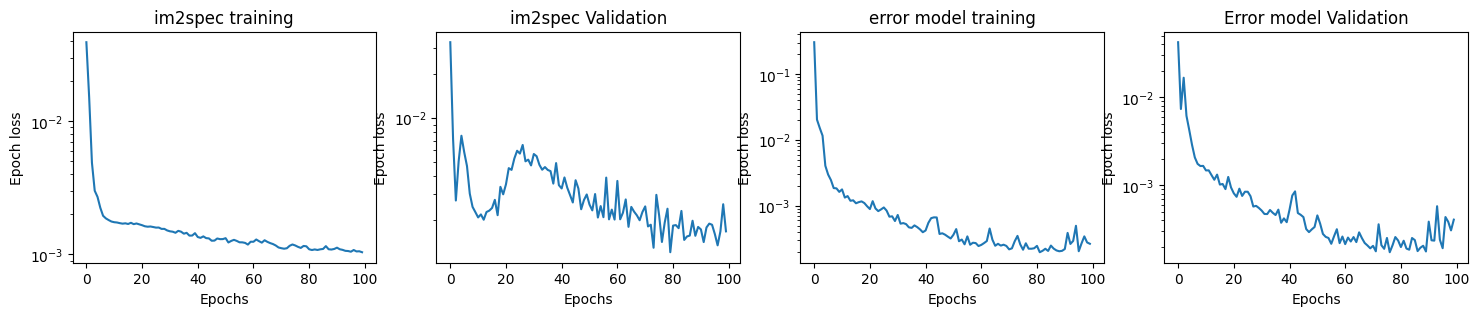

In [16]:

# ----------------------------
# 5) Train error model on images and estimated errors
# ----------------------------



error_training_dataset = TensorDataset(
    torch.tensor(images_tr_aug, dtype=torch.float32),
    torch.tensor(error_targets, dtype=torch.float32),
)


error_model, error_train_loss, error_val_loss = train_model(
    error_model,
    error_training_dataset,
    n_batches=6,
    lr=1e-3,
    patience=10,
    n_epochs=n_epochs_error,
    partial_train=True,
)

print("error model final train loss:", error_train_loss[-1])
print("error model final val loss:", error_val_loss[-1])

plot_training_loss([im2spec_train_loss], [im2spec_val_loss], error_train_loss, error_val_loss)

# Predict all errors

In [17]:
#Predict errors on the entire dataset using the trained error model
predicted_errors = predict_spectra(error_model, images, ensemble=False)
predicted_errors = np.clip(predicted_errors, 0, None)
print("predicted_errors shape:", np.asarray(predicted_errors).shape)
print("predicted_errors range:", float(np.min(predicted_errors)), float(np.max(predicted_errors)))

predicted_errors shape: (8192,)
predicted_errors range: 0.0 0.07632243633270264


## Acquisition function

In [22]:
from nnerror.training_functions import distance_acq_fn
from nnerror.plot_functions import plot_error_prediction, plot_spectra


#beta=0 is explotation. aq_fn is inverse to errors
aq_ind, aq_fn = distance_acq_fn(predicted_errors, beta = 0, lambda_ = 1, sample_next_points = 1, exclude_indices = [])
print(aq_fn.shape)


(8192,)


# Variance with test size

# Visualize acquisition results

In [20]:
for ind in aq_ind:

    # Acquisition point
    next_coordinate = scale_coordinates[ind]
    predicted_spectra = predict_spectra(imspec_model, images[ind:ind+1], ensemble = False)

    spectral_error, _, _ = err_estimation(imspec_model, images[ind:ind+1], spectra[ind:ind+1], error_type=error_type)
    # error_log.append(spectral_error.mean())
    plot_spectra([predicted_spectra], spectra[ind], spectral_error.mean())

NameError: name 'aq_ind' is not defined

## 3D error and acquisition view

In [ ]:
plot_error_prediction_3d(predicted_errors, aq_fn, scale_coordinates, aq_ind, alpha_scale=True,
                         colormap="jet", )

## Scale-specific error maps

In [ ]:
plot_scale_slider(scale_coordinates, predicted_errors, aq_fn, colormap="jet")

In [ ]:
# unique_scales = np.unique(scale_coordinates[:, 2])

# # min/max for color scaling
# global_error_min = predicted_errors.min()
# global_error_max = predicted_errors.max()
# global_aq_fn_min = aq_fn.min()
# global_aq_fn_max = aq_fn.max()

# #  min/max for X and Y coordinates across scales
# global_x_min = scale_coordinates[:, 0].min()
# global_x_max = scale_coordinates[:, 0].max()
# global_y_min = scale_coordinates[:, 1].min()
# global_y_max = scale_coordinates[:, 1].max()

# # loop through scales
# for s in unique_scales:
#     fig, axes = plt.subplots(1, 2, figsize=(16, 8))
#     fig.suptitle(f'Error and Acquisition Functions for Scale: {int(s)}', fontsize=16)

#     scale_mask = scale_coordinates[:, 2] == s
#     coords_for_scale = scale_coordinates[scale_mask, :2] # x, y coordinates
#     errors_for_scale = predicted_errors[scale_mask]
#     aq_fn_for_scale = aq_fn[scale_mask]

#     # error plot
#     sc1 = axes[0].scatter(coords_for_scale[:, 0], coords_for_scale[:, 1],
#                           c=errors_for_scale, cmap='jet', s=50, marker='o', edgecolors='none',
#                           vmin=global_error_min, vmax=global_error_max)
#     axes[0].set_title('Error Function')
#     axes[0].set_xlabel('Y')
#     axes[0].set_ylabel('X')
#     axes[0].set_aspect('equal', adjustable='box')
#     axes[0].set_xlim(global_x_min, global_x_max)
#     axes[0].set_ylim(global_y_min, global_y_max)
#     divider1 = make_axes_locatable(axes[0])
#     cax1 = divider1.append_axes("right", size="5%", pad=0.1)
#     fig.colorbar(sc1, cax=cax1)

#     # aqn function plot
#     sc2 = axes[1].scatter(coords_for_scale[:, 0], coords_for_scale[:, 1],
#                           c=aq_fn_for_scale, cmap='jet', s=50, marker='o', edgecolors='none',
#                           vmin=global_aq_fn_min, vmax=global_aq_fn_max)
#     axes[1].set_title('Acquisition Function')
#     axes[1].set_xlabel('Y')
#     axes[1].set_ylabel('X')
#     axes[1].set_aspect('equal', adjustable='box')
#     axes[1].set_xlim(global_x_min, global_x_max)
#     axes[1].set_ylim(global_y_min, global_y_max)
#     divider2 = make_axes_locatable(axes[1])
#     cax2 = divider2.append_axes("right", size="5%", pad=0.1)
#     fig.colorbar(sc2, cax=cax2)

#     plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
#     plt.show()

In [ ]:
output_type = 'latent'
posterior_spectra = predict_posterior(imspec_model, images, output_type = output_type)
posterior_trainset = predict_posterior(imspec_model, images_train, output_type = output_type)
plot_latent_space(posterior_spectra, posterior_trainset[initial_trainsize:],lat_order = [0, 1, 2])

In [ ]:
for s in unique_scales[::2]:
  scale_mask = scale_coordinates[:, 2] == s
  latent_space_scaled = posterior_spectra[scale_mask]

  # Latent space plot
  plot_latent_space(latent_space_scaled, posterior_trainset[initial_trainsize:], lat_order = [0,1,2])

  # Clustered latent space plot
  cluster_latent_space(latent_space_scaled, lat_order = [0, 1, 2], n_clusters = 3)


In [ ]:
#cluster_latent_space(posterior_spectra, lat_order = [0, 1, 2],  n_clusters = 3) # keep n_clusters < 5

In [ ]:
def split_augment(train_size, random_state = 42):

  images_train, images_test, spectra_train, spectra_test, s_coords_train, s_coords_test = train_test_split(
  images_all, spectra_all, swap_coordinates_all, train_size = train_size, random_state=42)



  images_tr_aug, spectra_tr_aug, _ = append_multiscale_data(images_train, spectra_train, scales=np.arange(WS_init, WS, d_WS),
                                                              coordinates=s_coords_train,
                                                              append_image_type=append_image_type)



  images_test_aug, spectra_test_aug, _ = append_multiscale_data(images_test, spectra_test, scales=np.arange(WS_init, WS, d_WS),
                                                              coordinates=s_coords_test,
                                                              append_image_type=append_image_type)

  return images_tr_aug, images_test_aug, spectra_tr_aug, spectra_test_aug

In [ ]:
def append_training_set(images, spectra, next_index, imgs_train, spectra_train, indices_train):
    """
    Append one acquired image/spectrum pair to the current training set.

    Args:
        images: Full image-patch array, shape `(N, H, W)`.
        spectra: Full spectra array, shape `(N, S)`.
        next_index: Index to append from `images` and `spectra`.
        imgs_train: Current training image array.
        spectra_train: Current training spectra array.
        indices_train: Current array of selected training indices.

    Returns:
        Tuple `(imgs_train, spectra_train, indices_train)` with the selected
        sample appended.
    """

    imgs_train = np.append(imgs_train, images[next_index].reshape(1, images.shape[1], images.shape[2]), axis = 0)

    spectra_train = np.append(spectra_train, spectra[next_index].reshape(1, spectra.shape[1]), axis = 0)

    indices_train = np.append(indices_train, next_index)

    return imgs_train, spectra_train, indices_train

In [24]:
# def plot_scale_specific_error_and_acquisition_maps(scale_coordinates, predicted_errors, aq_fn):
#     """
#     Plots error and acquisition functions for each unique scale.

#     Args:
#         scale_coordinates (np.ndarray): Array containing x, y, and scale coordinates.
#         predicted_errors (np.ndarray): Predicted error values corresponding to scale_coordinates.
#         aq_fn (np.ndarray): Acquisition function values corresponding to scale_coordinates.
#     """
#     unique_scales = np.unique(scale_coordinates[:, 2])

#     # min/max for color scaling
#     global_error_min = predicted_errors.min()
#     global_error_max = predicted_errors.max()
#     global_aq_fn_min = aq_fn.min()
#     global_aq_fn_max = aq_fn.max()

#     # min/max for X and Y coordinates across scales
#     # Add a small padding to prevent dots from being cut off
#     padding = 10 # Adjust padding value as needed
#     global_x_min = scale_coordinates[:, 0].min() - padding
#     global_x_max = scale_coordinates[:, 0].max() + padding
#     global_y_min = scale_coordinates[:, 1].min() - padding
#     global_y_max = scale_coordinates[:, 1].max() + padding

#     # loop through scales
#     for s in unique_scales:
#         fig, axes = plt.subplots(1, 2, figsize=(16, 8))
#         fig.suptitle(f'Error and Acquisition Functions for Scale: {int(s)}', fontsize=16)

#         scale_mask = scale_coordinates[:, 2] == s
#         coords_for_scale = scale_coordinates[scale_mask, :2] # x, y coordinates
#         errors_for_scale = predicted_errors[scale_mask]
#         aq_fn_for_scale = aq_fn[scale_mask]

#         # error plot
#         sc1 = axes[0].scatter(coords_for_scale[:, 0], coords_for_scale[:, 1],
#                               c=errors_for_scale, cmap='jet', s=50, marker='o', edgecolors='none',
#                               vmin=global_error_min, vmax=global_error_max)
#         axes[0].set_title('Error Function')
#         axes[0].set_xlabel('Y')
#         axes[0].set_ylabel('X')
#         axes[0].set_aspect('equal', adjustable='box')
#         axes[0].set_xlim(global_x_min, global_x_max)
#         axes[0].set_ylim(global_y_min, global_y_max)
#         divider1 = make_axes_locatable(axes[0])
#         cax1 = divider1.append_axes("right", size="5%", pad=0.1)
#         fig.colorbar(sc1, cax=cax1)

#         # aqn function plot
#         sc2 = axes[1].scatter(coords_for_scale[:, 0], coords_for_scale[:, 1],
#                               c=aq_fn_for_scale, cmap='jet', s=50, marker='o', edgecolors='none',
#                               vmin=global_aq_fn_min, vmax=global_aq_fn_max)
#         axes[1].set_title('Acquisition Function')
#         axes[1].set_xlabel('Y')
#         axes[1].set_ylabel('X')
#         axes[1].set_aspect('equal', adjustable='box')
#         axes[1].set_xlim(global_x_min, global_x_max)
#         axes[1].set_ylim(global_y_min, global_y_max)
#         divider2 = make_axes_locatable(axes[1])
#         cax2 = divider2.append_axes("right", size="5%", pad=0.1)
#         fig.colorbar(sc2, cax=cax2)

#         plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
#         plt.show()


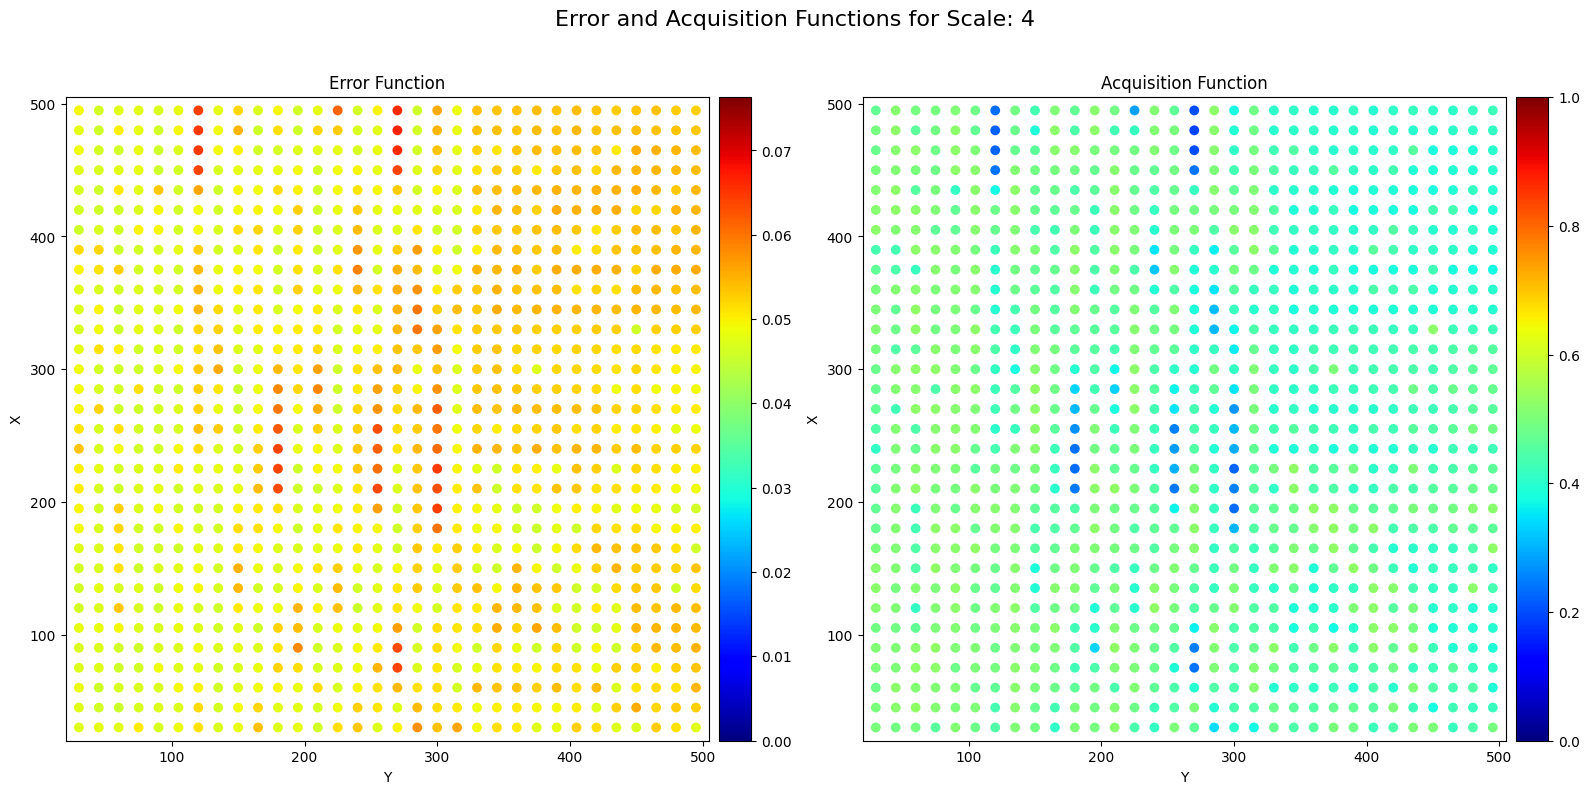

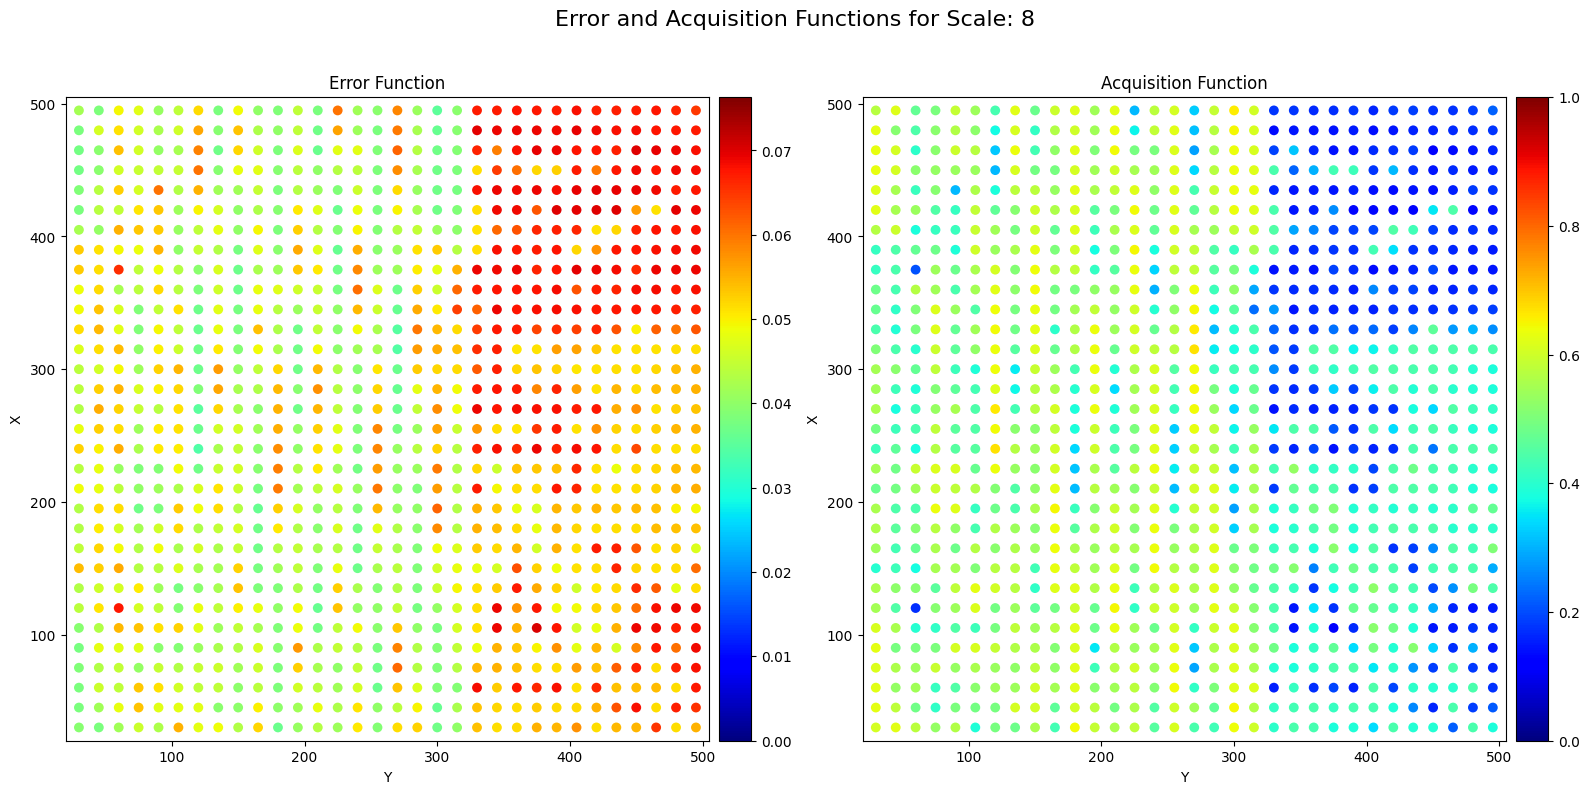

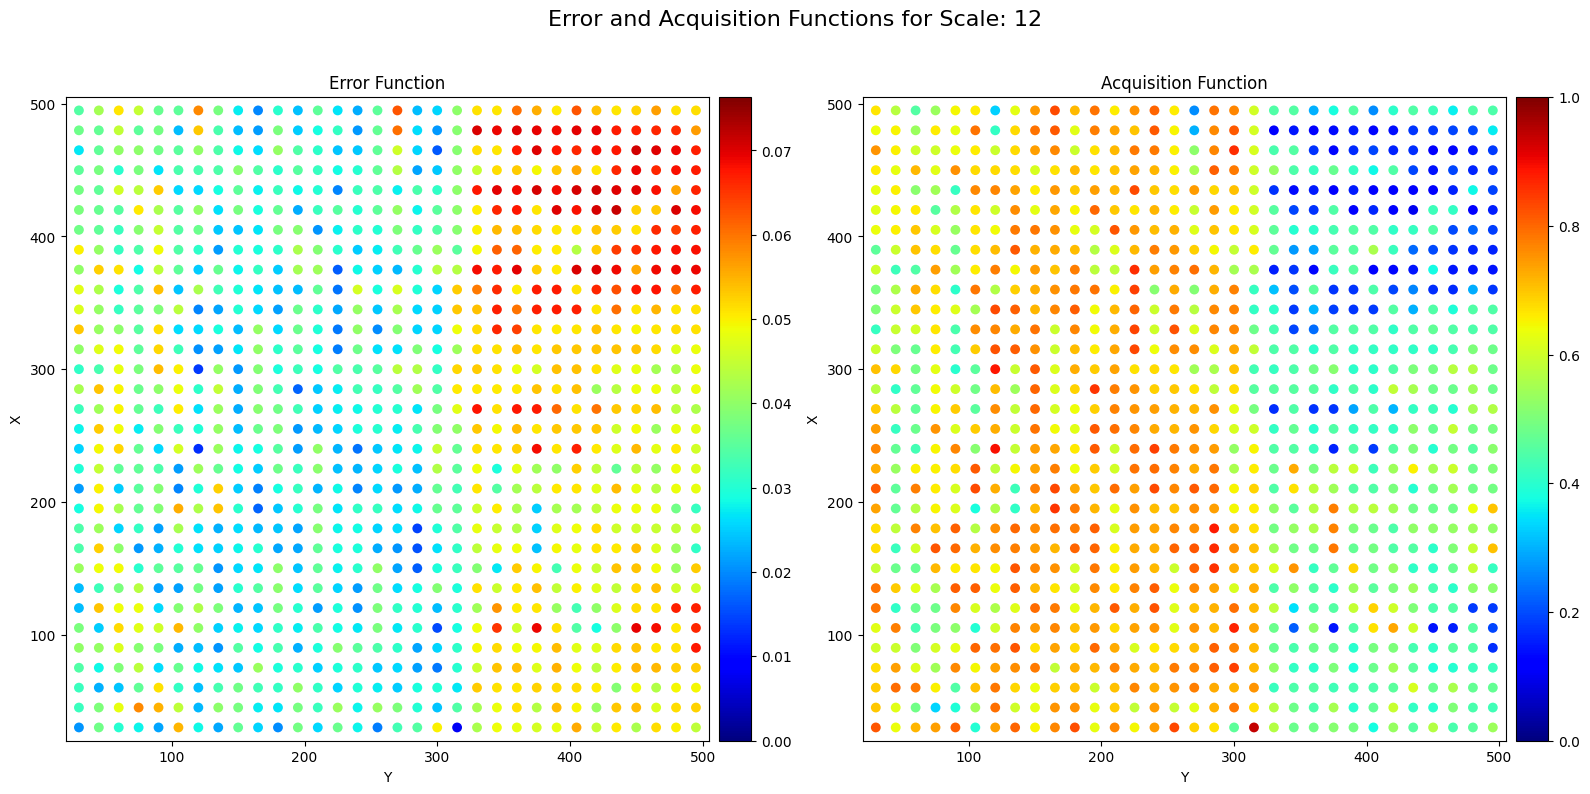

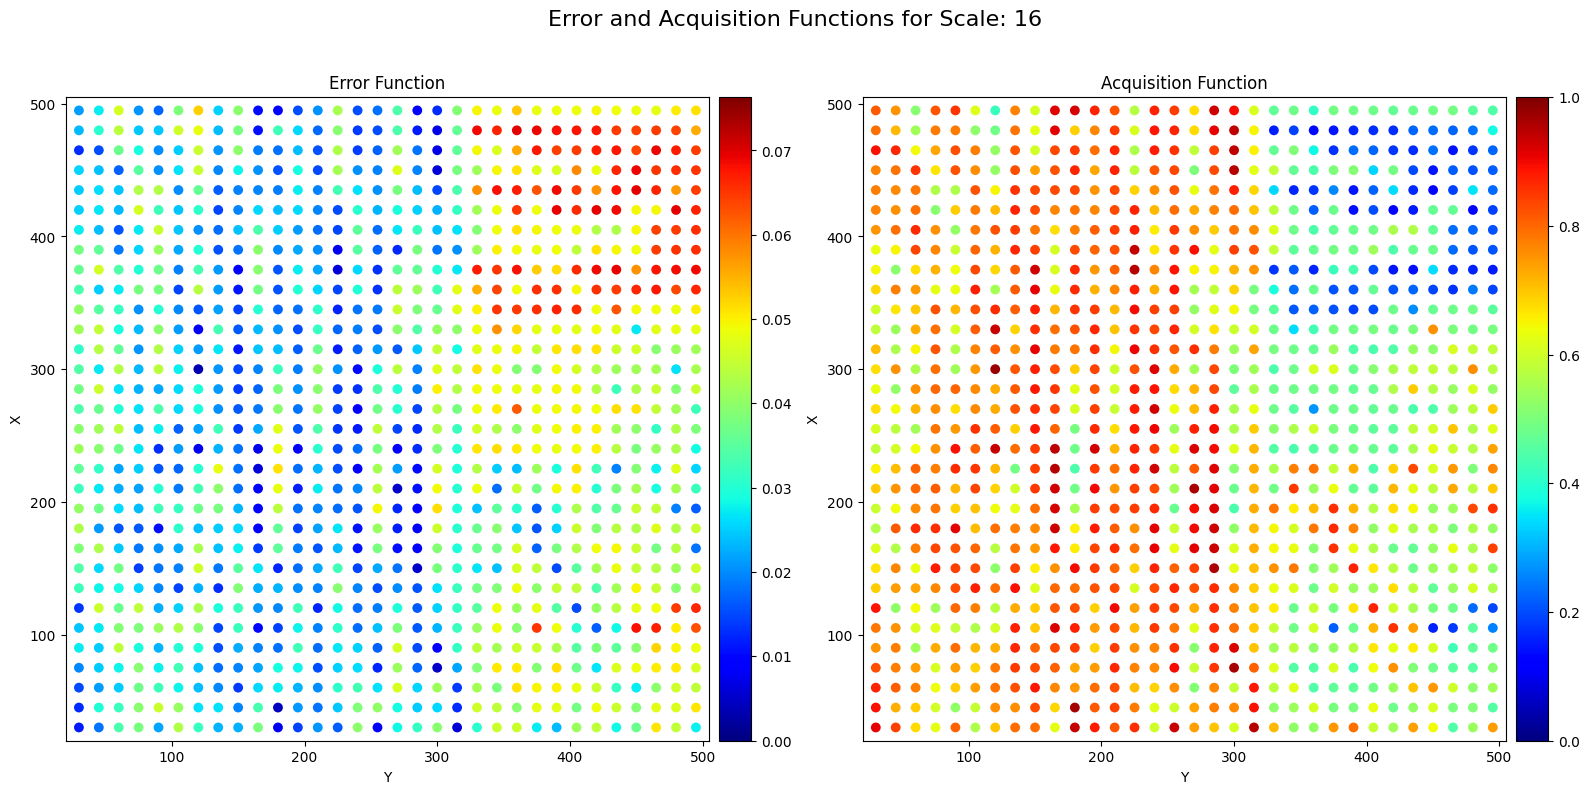

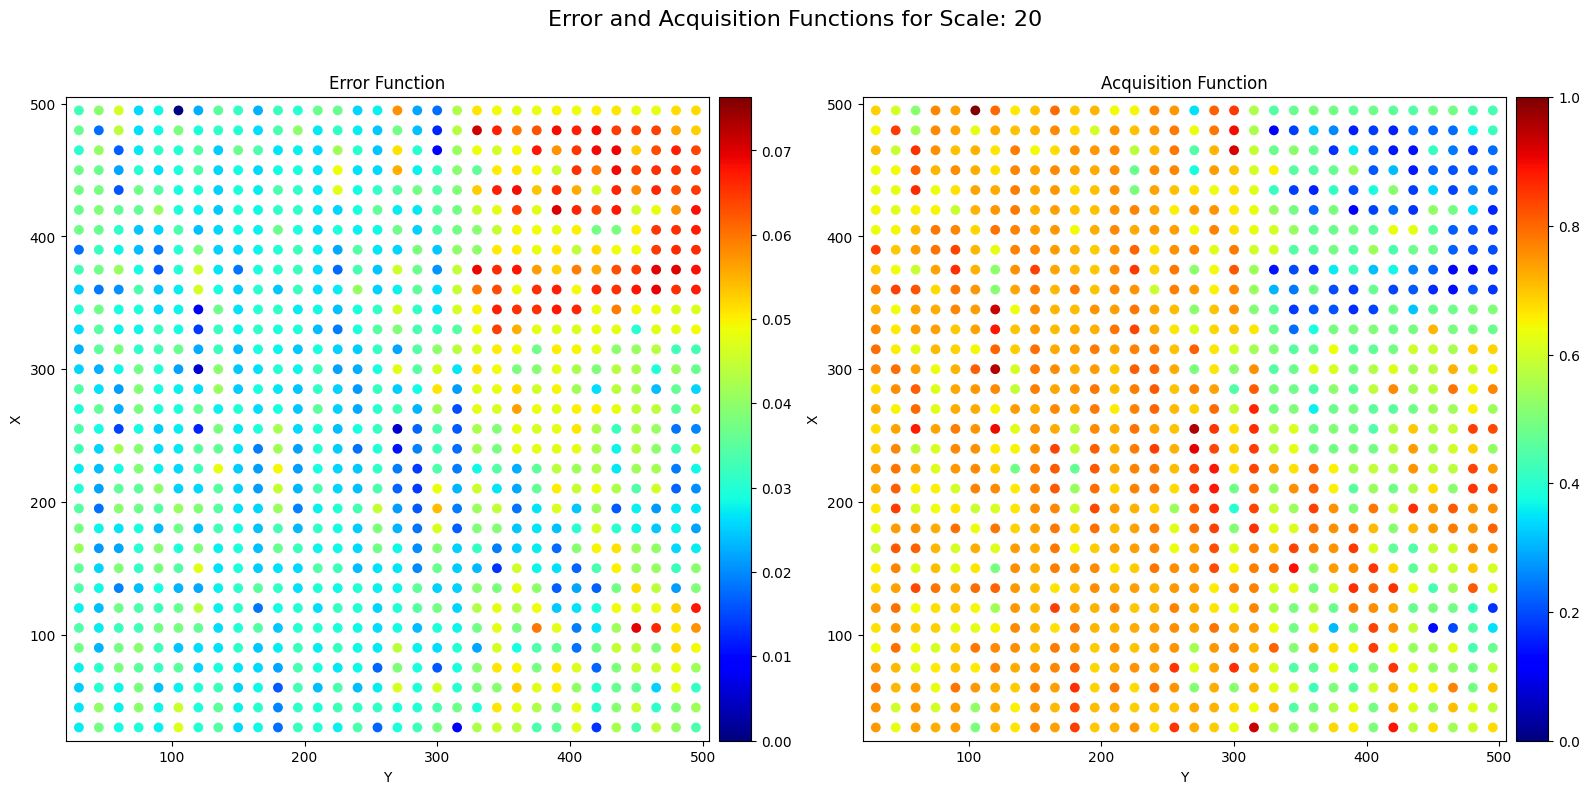

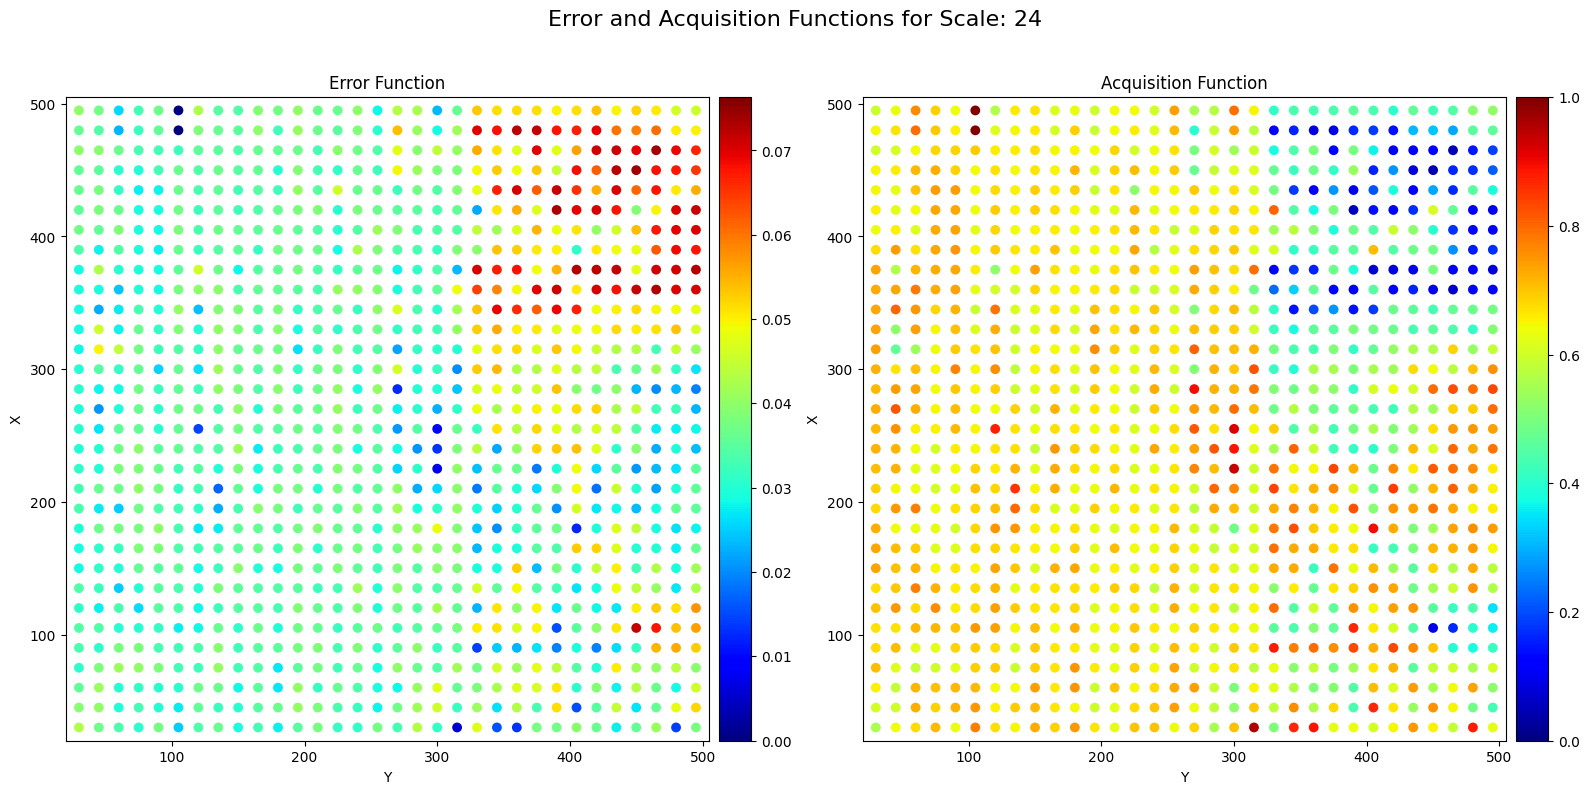

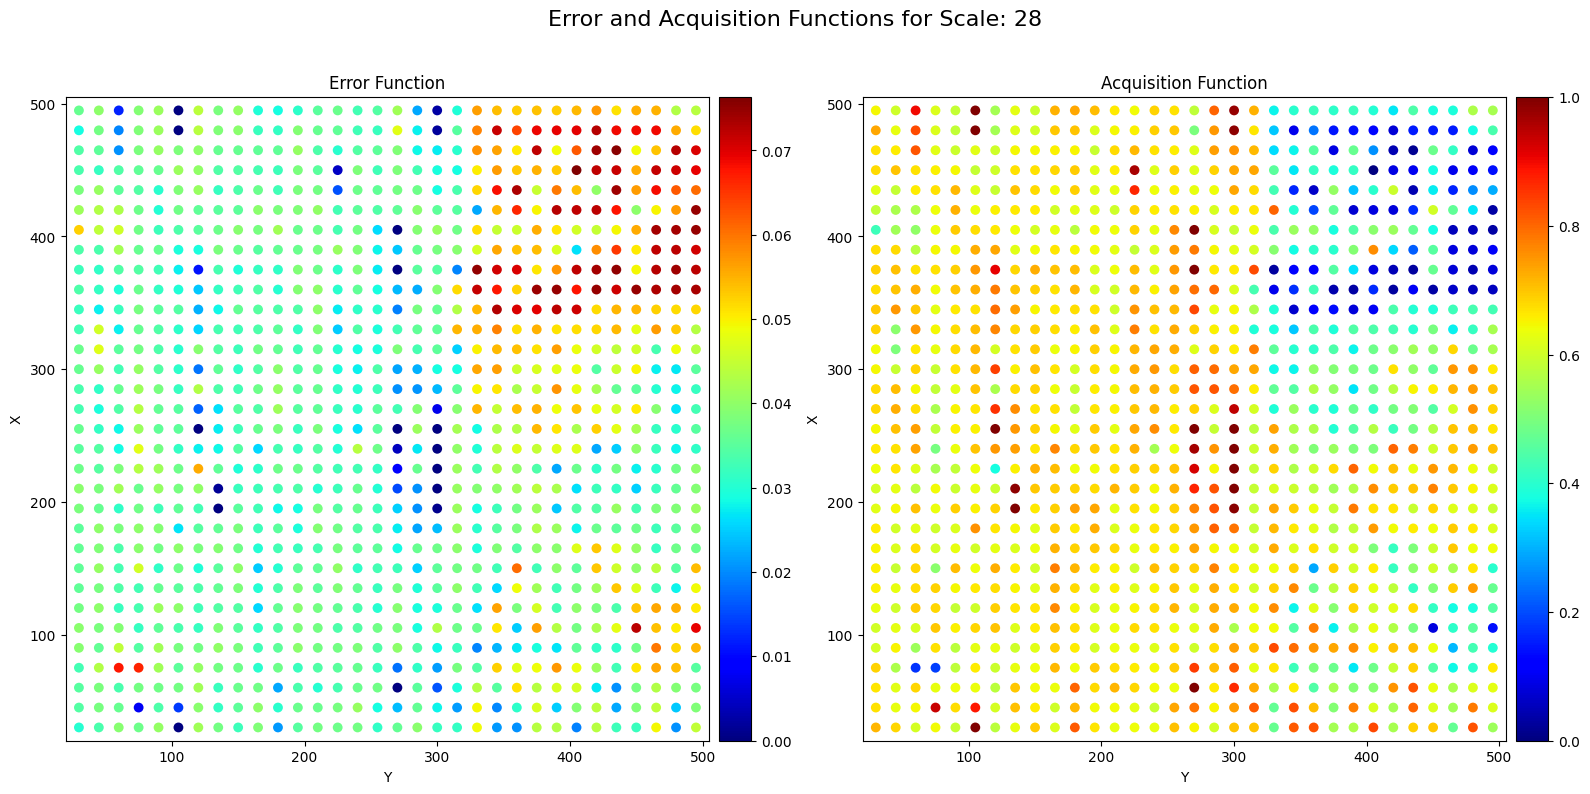

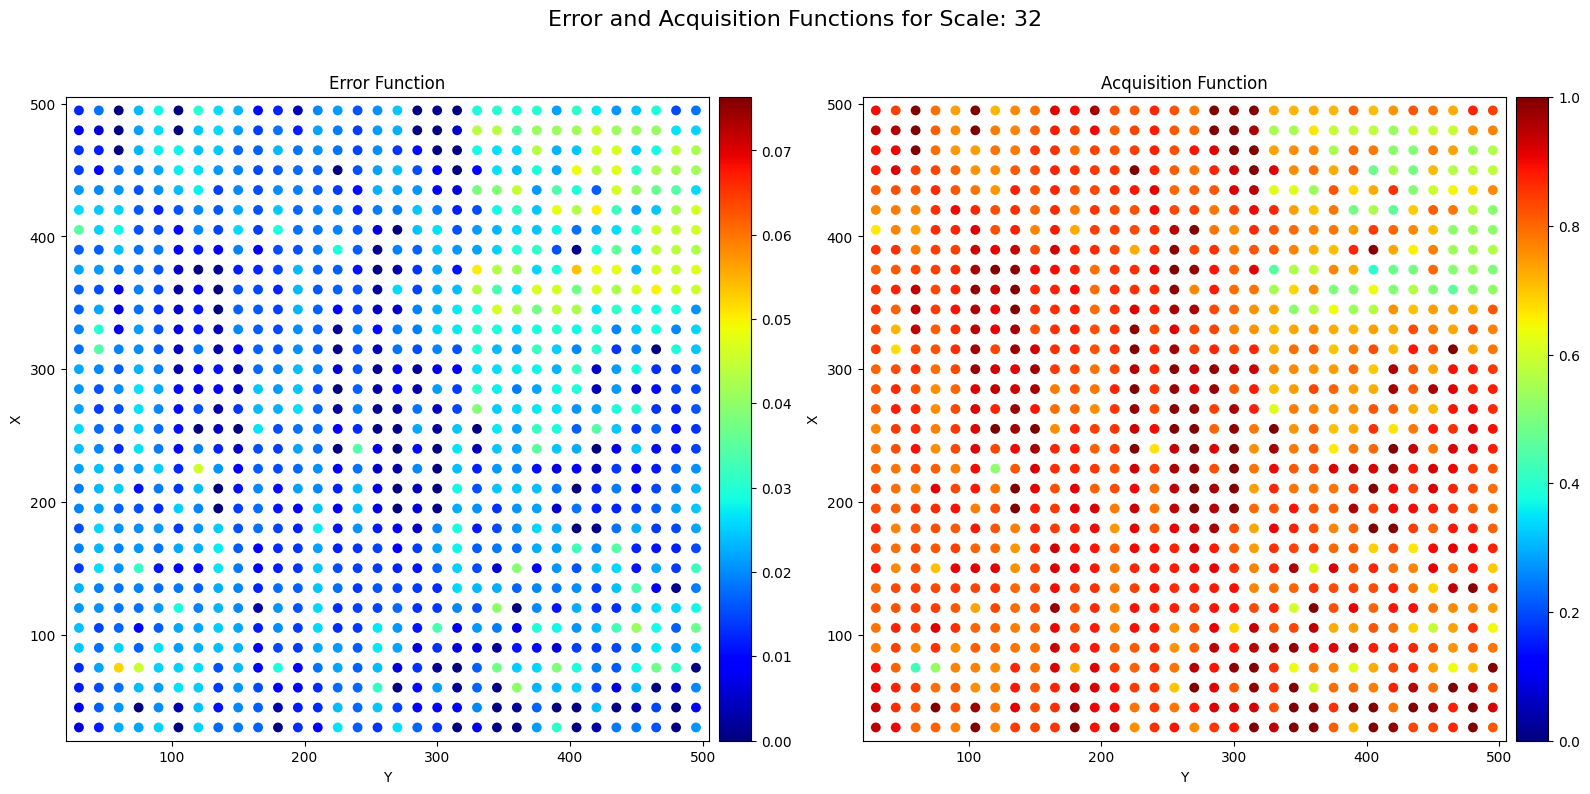

In [25]:
# Call the new plotting function
plot_scale_specific_error_and_acquisition_maps(scale_coordinates, predicted_errors, aq_fn)



Testing with test size: 0.1
Augmented images shape: (816, 32, 32), Augmented spectra shape: (816, 121), Augmented coordinates shape: (816, 3)
Augmented images shape: (7376, 32, 32), Augmented spectra shape: (7376, 121), Augmented coordinates shape: (7376, 3)


 91%|█████████ | 91/100 [00:31<00:03,  2.58it/s, train_loss=0.0014, val_loss=0.0019]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:34<00:00,  2.87it/s, train_loss=0.0014, val_loss=0.0015]


  Error targets train shape: (816, 1)
  Error targets test shape: (7376, 1)


 92%|█████████▏| 92/100 [00:12<00:01,  7.60it/s, train_loss=0.0001, val_loss=0.0002]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:13<00:00,  7.49it/s, train_loss=0.0001, val_loss=0.0001]


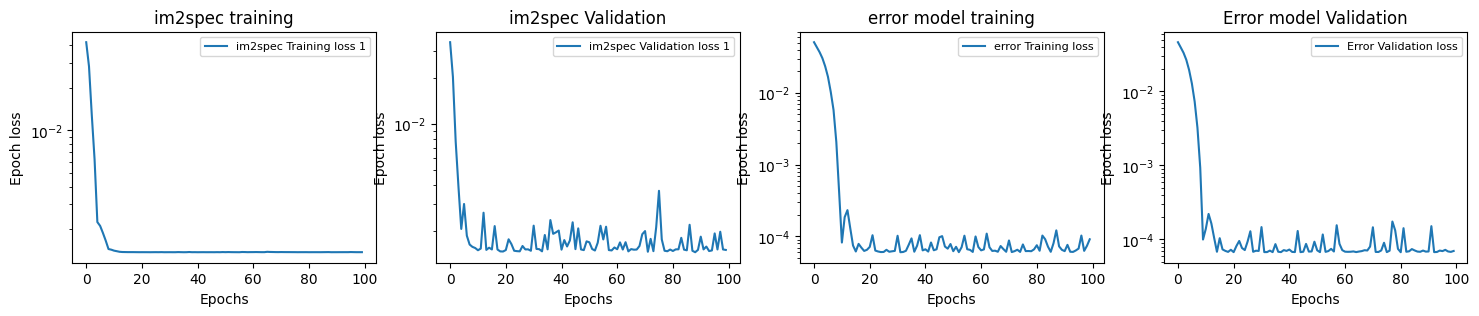


Testing with test size: 0.4
Augmented images shape: (3272, 32, 32), Augmented spectra shape: (3272, 121), Augmented coordinates shape: (3272, 3)
Augmented images shape: (4920, 32, 32), Augmented spectra shape: (4920, 121), Augmented coordinates shape: (4920, 3)


 91%|█████████ | 91/100 [00:35<00:03,  2.66it/s, train_loss=0.0024, val_loss=0.0016]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:38<00:00,  2.59it/s, train_loss=0.0016, val_loss=0.0015]


  Error targets train shape: (3272, 1)
  Error targets test shape: (4920, 1)


 91%|█████████ | 91/100 [00:20<00:02,  4.47it/s, train_loss=0.0001, val_loss=0.0001]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:22<00:00,  4.42it/s, train_loss=0.0001, val_loss=0.0001]


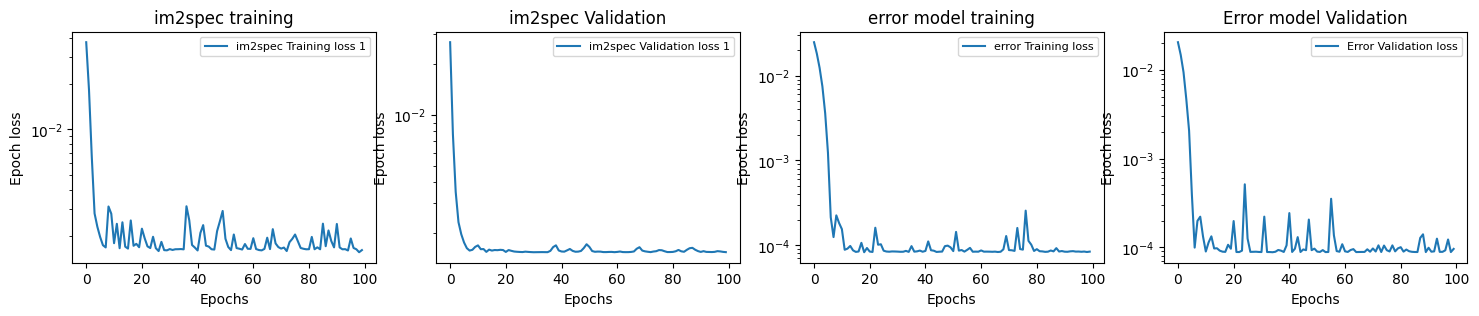


Testing with test size: 0.7000000000000001
Augmented images shape: (5728, 32, 32), Augmented spectra shape: (5728, 121), Augmented coordinates shape: (5728, 3)
Augmented images shape: (2464, 32, 32), Augmented spectra shape: (2464, 121), Augmented coordinates shape: (2464, 3)


 91%|█████████ | 91/100 [00:41<00:04,  2.24it/s, train_loss=0.0018, val_loss=0.0016]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:45<00:00,  2.19it/s, train_loss=0.0015, val_loss=0.0014]


  Error targets train shape: (5728, 1)
  Error targets test shape: (2464, 1)


 91%|█████████ | 91/100 [00:30<00:02,  3.02it/s, train_loss=0.0001, val_loss=0.0001]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:33<00:00,  2.95it/s, train_loss=0.0001, val_loss=0.0001]


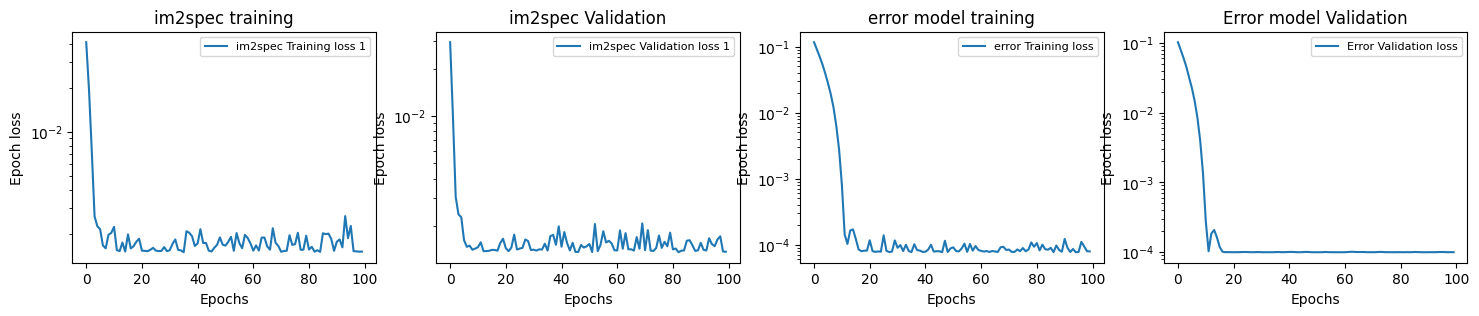

In [ ]:
train_sizes = np.arange(0.1, 1, 0.3)

im2spec_train_losses = []
im2spec_val_losses = []
im2spec_test_losses = []

error_train_losses = []
error_val_losses = []
error_test_losses = []

for ts in train_sizes:



    print(f"\nTesting with test size: {ts}")

    #original_images, original_spectra, original_coordinates = paired_images_spectra_1(full_image, cits_obj, hyperspectra, window_size = WS, coordinate_step = 15, image_norm=False, spectra_norm = False)
    images_train_ts, images_test_ts, spectra_train_ts, spectra_test_ts = split_augment(ts)


    if images_train_ts.shape[0] == 0 or images_test_ts.shape[0] == 0:
        print(f"Skipping test size {ts} due to insufficient training data.")
        continue

    # Train im2spec model on this train/test split
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    imspec_model_ts = FNO_im2spec(
        target_size=out_dim,
        latent_dim=3,
        hidden_channels=32,
        n_modes=(16, 16),
        n_layers=4,
    ).to(device)

    #imspec_model_ts = im2spec(feature_size=in_dim, target_size=out_dim, latent_dim=3).to(device)

    impsec_training_dataset_ts = TensorDataset(
        torch.tensor(images_train_ts, dtype=torch.float32),
        torch.tensor(spectra_train_ts, dtype=torch.float32),
    )
    impsec_val_dataset_ts = TensorDataset(
        torch.tensor(images_test_ts, dtype=torch.float32),
        torch.tensor(spectra_test_ts, dtype=torch.float32),
    )

    im2spec_model_ts, im2spec_train_loss_ts, im2spec_val_loss_ts = train_model(
        imspec_model_ts,
        impsec_training_dataset_ts,
        n_batches=6,
        lr=1e-3,
        patience=10,
        n_epochs=n_epochs_error,
        partial_train= False,
        val_dataset = impsec_val_dataset_ts,
        use_swa = True,
        last_swa_epochs = 0.1
    )


    im2spec_train_losses.append(im2spec_train_loss_ts)
    im2spec_val_losses.append(im2spec_val_loss_ts)

    imspec_model_ts.eval()
    with torch.no_grad():
        x_test_ts = torch.tensor(images_test_ts, dtype=torch.float32, device=device)
        y_test_ts = torch.tensor(spectra_test_ts, dtype=torch.float32, device=device)
        test_pred_ts = imspec_model_ts.predict(x_test_ts)
        im2spec_test_loss_ts = torch.nn.functional.mse_loss(test_pred_ts, y_test_ts).item()
    im2spec_test_losses.append(im2spec_test_loss_ts)

    # Train error model
    error_mean_ts, _, _ = err_estimation(imspec_model_ts, images_train_ts, spectra_train_ts, error_type=error_type)
    error_targets_ts = error_mean_ts.astype(np.float32).reshape(-1, 1)

    # Add error estimation for the test set
    error_mean_test_ts, _, _ = err_estimation(imspec_model_ts, images_test_ts, spectra_test_ts, error_type=error_type)
    error_targets_test_ts = error_mean_test_ts.astype(np.float32).reshape(-1, 1)

    print(f"  Error targets train shape: {error_targets_ts.shape}")
    print(f"  Error targets test shape: {error_targets_test_ts.shape}")

    latent_dim_ts = imspec_model_ts.encoder(torch.tensor(images[:1], dtype=torch.float32, device=device).unsqueeze(1)).shape[1]
    error_model_ts = CustomDecoder(encoder=imspec_model_ts.encoder, embed_dim=latent_dim_ts, target_size=1).to(device)

    error_training_dataset_ts = TensorDataset(
        torch.tensor(images_train_ts, dtype=torch.float32),
        torch.tensor(error_targets_ts, dtype=torch.float32),
    )

    error_model_ts, error_train_loss_ts, error_val_loss_ts = train_model(
        error_model_ts,
        error_training_dataset_ts,
        n_batches=6,
        lr=1e-3,
        patience=10,
        n_epochs=n_epochs_error,
        partial_train=True,
        use_swa = True,
        last_swa_epochs = 0.1
    )

    plot_training_loss([im2spec_train_loss_ts], [im2spec_val_loss_ts], error_train_loss_ts, error_val_loss_ts)

    # Append all losses to the lists for box plotting
    error_train_losses.append(error_train_loss_ts)
    error_test_losses.append(error_mean_test_ts)
    error_val_losses.append(error_val_loss_ts)

/tmp/ipykernel_346/3092958049.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot(im2spec_train_losses, labels=[f"{ts:.2f}" for ts in train_sizes])
/tmp/ipykernel_346/3092958049.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(im2spec_val_losses, labels=[f"{ts:.2f}" for ts in train_sizes])


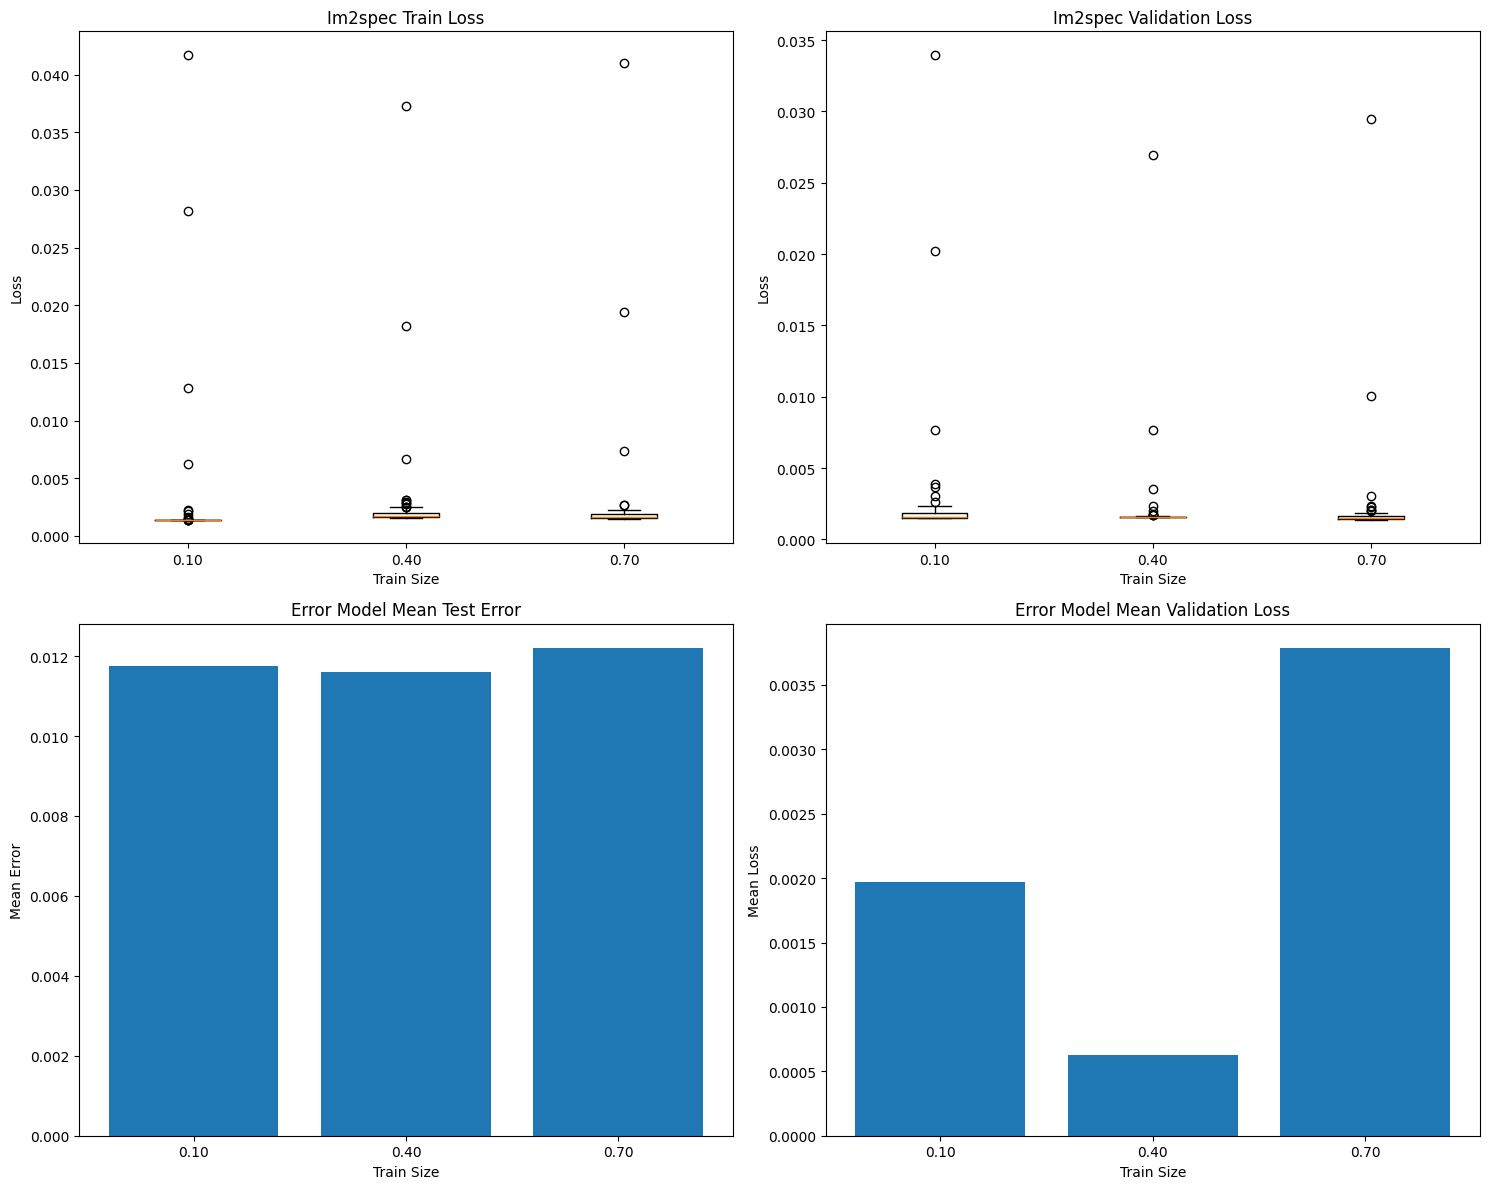

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate the mean validation loss for the error model for bar plotting
mean_error_val_losses = [np.mean(losses) for losses in error_val_losses]

# Calculate mean of error_test_losses for bar plotting
mean_error_test_losses_per_train_size = [np.mean(err_arr) for err_arr in error_test_losses]

# Plot charts on a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Im2spec Train Loss Box Plot
axes[0, 0].boxplot(im2spec_train_losses, labels=[f"{ts:.2f}" for ts in train_sizes])
axes[0, 0].set_title("Im2spec Train Loss")
axes[0, 0].set_xlabel("Train Size")
axes[0, 0].set_ylabel("Loss")

# Im2spec Validation Loss Box Plot
axes[0, 1].boxplot(im2spec_val_losses, labels=[f"{ts:.2f}" for ts in train_sizes])
axes[0, 1].set_title("Im2spec Validation Loss")
axes[0, 1].set_xlabel("Train Size")
axes[0, 1].set_ylabel("Loss")

# Error Model Mean Test Error Bar Chart
axes[1, 0].bar([f"{ts:.2f}" for ts in train_sizes], mean_error_test_losses_per_train_size)
axes[1, 0].set_title("Error Model Mean Test Error")
axes[1, 0].set_xlabel("Train Size")
axes[1, 0].set_ylabel("Mean Error")

# Error Model Mean Validation Loss Bar Chart
axes[1, 1].bar([f"{ts:.2f}" for ts in train_sizes], mean_error_val_losses)
axes[1, 1].set_title("Error Model Mean Validation Loss")
axes[1, 1].set_xlabel("Train Size")
axes[1, 1].set_ylabel("Mean Loss")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# grouping
df_errors = pd.DataFrame({
    'x': scale_coordinates[:, 0],
    'y': scale_coordinates[:, 1],
    'scale': scale_coordinates[:, 2],
    'error': predicted_errors,
    'original_index': np.arange(len(predicted_errors)) # Store original indices
})

# x,y grouping by error
# idx min gets the index of the points with min error in the scale
# then get full row with x and y coords.
min_errors_df = df_errors.loc[df_errors.groupby(['x', 'y'])['error'].idxmin()].reset_index(drop=True)

# relevant columns, including the original_index for mapping back
min_errors_xy = min_errors_df[['x', 'y', 'error', 'original_index']]

print("Minimum error for each (x, y) coordinate:")
display(min_errors_xy.head())

print("Shape of min_errors_xy (x, y, min_error, original_index):")
print(min_errors_xy.shape)

Minimum error for each (x, y) coordinate:


,x,y,error,original_index
0,30.0,30.0,0.003202,2048
1,30.0,45.0,0.004596,2080
2,30.0,60.0,0.002892,2112
3,30.0,75.0,0.004521,1120
4,30.0,90.0,0.003879,1152


Shape of min_errors_xy (x, y, min_error, original_index):
(1024, 4)


In [ ]:
# Calculate aq_fn for the entire dataset based on min_errors_xy
from nnerror.training_functions import distance_acq_fn

aq_ind, aq_fn = distance_acq_fn(min_errors_xy['error'].values,
                                beta=0,
                                lambda_=1,
                                sample_next_points=len(min_errors_xy), # Get values for all
                                exclude_indices=[])
print("Shape of aq_fn:", aq_fn.shape)


In [ ]:
from nnerror.training_functions import distance_acq_fn, append_training_set, train_model, err_estimation, predict_spectra
from nnerror.plot_functions import plot_error_prediction, plot_spectra, plot_error_prediction_3d
from nnerror.networks import CustomDecoder # Assuming CustomDecoder is needed for error_model retraining
from sklearn.model_selection import train_test_split # Added import for train_test_split


#al denotes variables used for active learning

# initialize variables for the acquisition loop
acquisition_iterations = 50  # number of iterations
num_new_points = 10  # points per iteration

error_log = [] # reinitialize error_log for tracking

# storing losses
im2spec_al_train_losses = []
im2spec_al_val_losses = []
error_al_train_losses = []
error_al_val_losses = []


# original indices for the full dataset
original_indices = np.arange(len(images))

# aqn function for all available x,y locations
_, initial_aq_fn_values_all = distance_acq_fn(min_errors_xy['error'].values,
                                                beta=0,
                                                lambda_=1,
                                                sample_next_points=len(min_errors_xy), # Get values for all
                                                exclude_indices=[])

# initialize training set as empty array
current_images_train = np.empty((0, images.shape[1], images.shape[2]), dtype=images.dtype)
current_spectra_train = np.empty((0, spectra.shape[1]), dtype=spectra.dtype)
current_indices_train = np.empty((0,), dtype=np.int64)

#redo test train split to ensure there is something in the train set initially

#all available original indices
all_available_indices = min_errors_xy['original_index'].values

#
initial_train_indices, _ = train_test_split(
    all_available_indices, test_size=0.9, random_state=42
)

for next_index in initial_train_indices:
    current_images_train, current_spectra_train, current_indices_train = append_training_set(
        images, spectra, next_index, current_images_train, current_spectra_train, current_indices_train
    )


for i in range(acquisition_iterations):
    print(f"\nActive Learning Iteration {i+1}/{acquisition_iterations}")

    # ensuring that the same point does not get selected
    # filter out points whose original_index is already in current_indices_train
    available_min_errors_xy = min_errors_xy[~min_errors_xy['original_index'].isin(current_indices_train)]

    if len(available_min_errors_xy) == 0:
        print(f"No more points to acquire after {i} iterations.")
        break

    aq_ind_df, _ = distance_acq_fn(available_min_errors_xy['error'].values,
                                            beta=0,
                                            lambda_=1,
                                            sample_next_points=num_new_points,
                                            exclude_indices=[])

    # get original indices of the new points
    newly_acquired_original_indices = available_min_errors_xy.iloc[aq_ind_df]['original_index'].values

    # use the append_training_set function for each newly acquired point
    for next_index in newly_acquired_original_indices:
        current_images_train, current_spectra_train, current_indices_train = append_training_set(
            images, spectra, next_index, current_images_train, current_spectra_train, current_indices_train
        )

    # error of new points for logging
    new_images = images[newly_acquired_original_indices]
    new_spectra = spectra[newly_acquired_original_indices]

    error_mean_new_points, _, _ = err_estimation(imspec_model, new_images, new_spectra, error_type=error_type)
    error_log.append(error_mean_new_points.mean())


    # recreate datasets
    im2spec_al_training_dataset = TensorDataset(
        torch.tensor(current_images_train, dtype=torch.float32),
        torch.tensor(current_spectra_train, dtype=torch.float32),
    )

    # validation dataset
    im2spec_al_val_dataset = TensorDataset(
        torch.tensor(images_test_aug, dtype=torch.float32),
        torch.tensor(spectra_test_aug, dtype=torch.float32),
    )

    # retrain imspec_model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if model_type == 'FNO':
        imspec_model = FNO_im2spec(
            target_size=out_dim,
            latent_dim=3,
            hidden_channels=32,
            n_modes=(16, 16),
            n_layers=4,
        ).to(device)
    elif model_type == 'im2spec':
        imspec_model = im2spec(feature_size=in_dim, target_size=out_dim, latent_dim=3).to(device)
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    imspec_model, al_im2spec_train_loss, al_im2spec_val_loss = train_model(
        imspec_model,
        im2spec_al_training_dataset,
        n_batches=6,
        lr=1e-3,
        patience= 10,
        n_epochs=n_epochs_im2spec // 5, #reduced epochs for faster retraining
        partial_train=False,
        val_dataset=im2spec_al_val_dataset,
        use_swa=True,
    )
    im2spec_al_train_losses.append(al_im2spec_train_loss[-1])
    im2spec_al_val_losses.append(al_im2spec_val_loss[-1])

    # estimate errors again with the appended dataset
    error_mean_al, _, _ = err_estimation(imspec_model, current_images_train, current_spectra_train, error_type=error_type)
    error_targets_al = error_mean_al.astype(np.float32).reshape(-1, 1)

    # retrain and reinitialize error model
    with torch.no_grad():
        latent_dim = imspec_model.encoder(torch.tensor(images[:1], dtype=torch.float32, device=device).unsqueeze(1)).shape[1]
    error_model = CustomDecoder(encoder=imspec_model.encoder, embed_dim=latent_dim, target_size=1).to(device)

    error_al_training_dataset = TensorDataset(
        torch.tensor(current_images_train, dtype=torch.float32),
        torch.tensor(error_targets_al, dtype=torch.float32),
    )

    # test set errors to evaluate error model
    error_mean_test_al, _, _ = err_estimation(imspec_model, images_test_aug, spectra_test_aug, error_type=error_type)
    error_targets_test_al = error_mean_test_al.astype(np.float32).reshape(-1, 1)

    error_al_val_dataset = TensorDataset(
        torch.tensor(images_test_aug, dtype=torch.float32),
        torch.tensor(error_targets_test_al, dtype=torch.float32),
    )

    error_model, al_error_train_loss, al_error_val_loss = train_model(
        error_model,
        error_al_training_dataset,
        n_batches=6,
        lr=1e-3,
        patience=5,
        n_epochs=n_epochs_error // 5,
        partial_train=True,
        val_dataset=error_al_val_dataset,
    )
    error_al_train_losses.append(al_error_train_loss[-1])
    error_al_val_losses.append(al_error_val_loss[-1])

Initialized active training set with 102 samples (approx 10% of total)...

Active Learning Iteration 1/50
Retraining models with 112 training samples...


100%|██████████| 20/20 [00:01<00:00, 13.49it/s, train_loss=0.0014, val_loss=0.0040]


SWA triggered at epoch 18


100%|██████████| 20/20 [00:01<00:00, 15.31it/s, train_loss=0.0008, val_loss=0.0014]


  IM2SPEC AL Train Loss: 0.0014, IM2SPEC AL Val (Test) Loss: 0.0040
  Error Model AL Train Loss: 0.0008, Error Model AL Val (Test) Loss: 0.0014

Active Learning Iteration 2/50
Retraining models with 122 training samples...


...

  IM2SPEC AL Train Loss: 0.0015, IM2SPEC AL Val (Test) Loss: 0.0087
  Error Model AL Train Loss: 0.0001, Error Model AL Val (Test) Loss: 0.0005

Active Learning Iteration 50/50
Retraining models with 602 training samples...


100%|██████████| 20/20 [00:02<00:00,  9.22it/s, train_loss=0.0014, val_loss=0.0067]


SWA triggered at epoch 18


100%|██████████| 20/20 [00:01<00:00, 11.69it/s, train_loss=0.0001, val_loss=0.0004]

  IM2SPEC AL Train Loss: 0.0014, IM2SPEC AL Val (Test) Loss: 0.0067
  Error Model AL Train Loss: 0.0001, Error Model AL Val (Test) Loss: 0.0004

Final active training set size: 602
Final acquired indices count: 602
